# 02 - Modelado: Detección de Fraude
**NovaPay Fraud Shield** | Desafío de Tripulaciones - Grupo 1

Modelos evaluados: Logistic Regression, Random Forest, XGBoost  
Técnicas: Pipeline, LabelEncoder, OneHotEncoding, StandardScaler, class_weight, threshold tuning

## 01 - Imports

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score,
    fbeta_score
)
from xgboost import XGBClassifier
from category_encoders import TargetEncoder
import joblib

SEED = 42
np.random.seed(SEED)

## 02 - Carga de datos

In [35]:
df = pd.read_csv('../data/synthetic_fin_data_CLEAN.csv')
print('Shape:', df.shape)
print('\nDistribución target:')
print(df['isFraud'].value_counts())
print(f'\nRatio fraude: {df["isFraud"].mean():.2%}')

Shape: (273213, 14)

Distribución target:
isFraud
0    265000
1      8213
Name: count, dtype: int64

Ratio fraude: 3.01%


## 03 - Feature Engineering

In [36]:
# Flag de país de alto riesgo
high_risk_countries = ['KH', 'CN', 'NG', 'CI', 'VE']
df['is_high_risk_country'] = df['ip_country'].isin(high_risk_countries).astype(int)

# Flag de categoría de alto riesgo
high_risk_categories = ['crypto', 'electronics']
df['is_high_risk_category'] = df['merchant_category'].isin(high_risk_categories).astype(int)

print('Features creadas correctamente')
df.head(3)

Features creadas correctamente


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_the_day,ip_country,merchant_category,balance_discrepancy,is_high_risk_country,is_high_risk_category
0,162,CASH_OUT,183806.32,C691771226,19391.0,0.00,C1416312719,382572.19,566378.51,0,18,ES,transport,-164415.32,0,0
1,137,PAYMENT,521.37,C203378011,0.0,0.00,M42773300,0.00,0.00,0,17,GB,transport,-521.37,0,0
2,179,PAYMENT,3478.18,C1698571270,19853.0,16374.82,M643984524,0.00,0.00,0,11,DE,restaurant,0.00,0,0


## 04 - Preparación de features y target

In [37]:
# Features numéricas
num_features = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'is_high_risk_country', 'is_high_risk_category'
]

# Features categóricas para OHE
cat_features_ohe = ['type', 'merchant_category']

# Feature categórica para TargetEncoder (alta cardinalidad)
cat_features_te = ['ip_country']

# Features finales (sin LabelEncoder, sin ip_country_encoded)
all_features = num_features + cat_features_ohe + cat_features_te

X = df[all_features]
y = df['isFraud']

print('Features:', X.shape)
print('Target:', y.shape)

Features: (273213, 10)
Target: (273213,)


## 05 - Train/Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y  # Mantiene el ratio de fraude en train y test
)

print(f'Train: {X_train.shape} | Fraude en train: {y_train.mean():.2%}')
print(f'Test:  {X_test.shape}  | Fraude en test:  {y_test.mean():.2%}')

Train: (218570, 10) | Fraude en train: 3.01%
Test:  (54643, 10)  | Fraude en test:  3.01%


## 06 - Definición de Pipelines

In [39]:
# Preprocessor correcto
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_ohe),
    # TargetEncoder aprende probabilidad de fraude por país, solo con X_train
    ('cat_te', TargetEncoder(min_samples_leaf=20, smoothing=10), cat_features_te)
])

# Ratio para scale_pos_weight de XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# Pipeline Logistic Regression
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        random_state=SEED,
        max_iter=1000
    ))
])

# Pipeline Random Forest
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ))
])

# Pipeline XGBoost
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

print('Pipelines definidos correctamente')

scale_pos_weight: 32.27
Pipelines definidos correctamente


## 07 - Entrenamiento y Evaluación


MODELO: Logistic Regression | Threshold: 0.5
              precision    recall  f1-score   support

    Legítimo       1.00      0.99      1.00     53000
      Fraude       0.85      0.97      0.90      1643

    accuracy                           0.99     54643
   macro avg       0.92      0.98      0.95     54643
weighted avg       0.99      0.99      0.99     54643

ROC-AUC: 0.9984


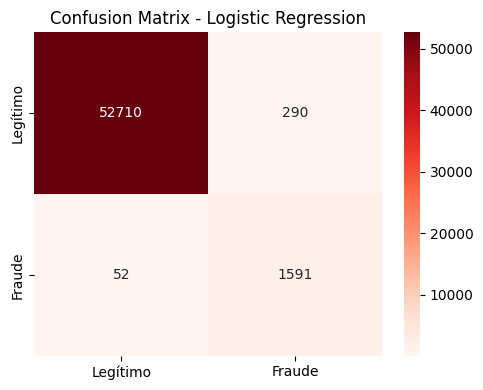


MODELO: Random Forest | Threshold: 0.5
              precision    recall  f1-score   support

    Legítimo       1.00      1.00      1.00     53000
      Fraude       1.00      0.96      0.98      1643

    accuracy                           1.00     54643
   macro avg       1.00      0.98      0.99     54643
weighted avg       1.00      1.00      1.00     54643

ROC-AUC: 0.9986


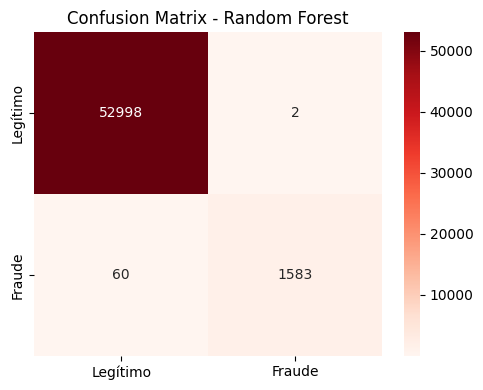


MODELO: XGBoost | Threshold: 0.5
              precision    recall  f1-score   support

    Legítimo       1.00      1.00      1.00     53000
      Fraude       0.97      0.99      0.98      1643

    accuracy                           1.00     54643
   macro avg       0.98      0.99      0.99     54643
weighted avg       1.00      1.00      1.00     54643

ROC-AUC: 0.9999


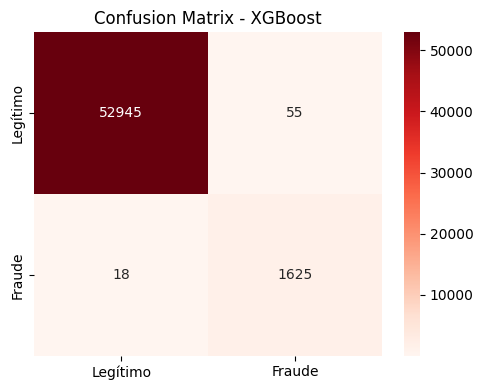

In [40]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test, threshold=0.5):
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    print(f'\n{"="*50}')
    print(f'MODELO: {name} | Threshold: {threshold}')
    print(f'{"="*50}')
    print(classification_report(y_test, y_pred, target_names=['Legítimo', 'Fraude']))
    print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Legítimo', 'Fraude'],
                yticklabels=['Legítimo', 'Fraude'])
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.savefig(f'../reports/confusion_matrix_{name.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()
    
    return pipeline, y_proba

# Entrenar los tres modelos
pipe_lr, proba_lr   = evaluate_model('Logistic Regression', pipe_lr, X_train, X_test, y_train, y_test)
pipe_rf, proba_rf   = evaluate_model('Random Forest', pipe_rf, X_train, X_test, y_train, y_test)
pipe_xgb, proba_xgb = evaluate_model('XGBoost', pipe_xgb, X_train, X_test, y_train, y_test)

## 08 - Curvas ROC comparativas

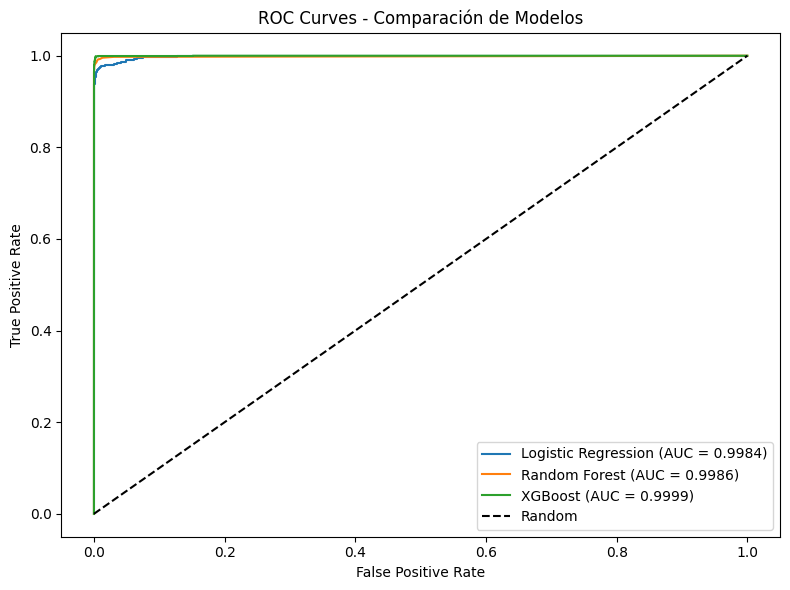

In [41]:
plt.figure(figsize=(8, 6))

for name, proba in [('Logistic Regression', proba_lr),
                     ('Random Forest', proba_rf),
                     ('XGBoost', proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Comparación de Modelos')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/roc_curves_comparison.png', dpi=150)
plt.show()

## 09 - Threshold Tuning (XGBoost)

Mejor threshold (F2): 0.45
F2 en mejor threshold: 0.9846


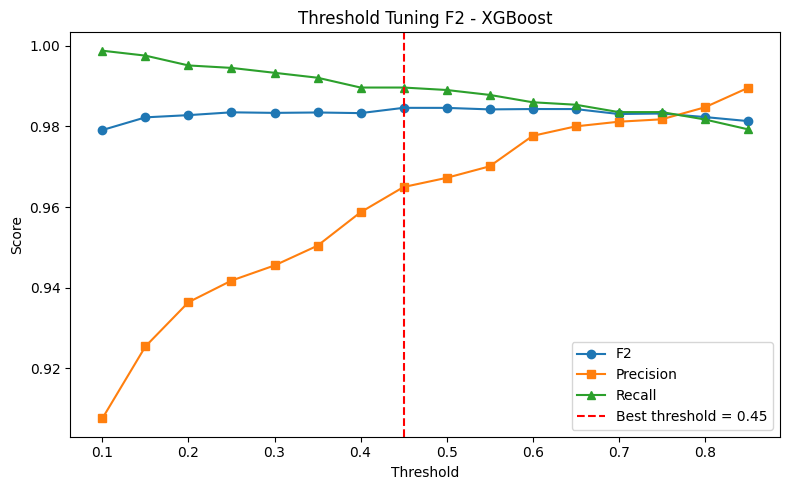

In [42]:
# Buscamos el threshold que maximiza F2 (prioriza Recall sobre Precision)
thresholds = np.arange(0.1, 0.9, 0.05)
f2_scores = []
precision_scores = []
recall_scores = []

for t in thresholds:
    y_pred_t = (proba_xgb >= t).astype(int)
    f2_scores.append(fbeta_score(y_test, y_pred_t, beta=2, zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_t, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_t))

best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Mejor threshold (F2): {best_threshold:.2f}')
print(f'F2 en mejor threshold: {max(f2_scores):.4f}')

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f2_scores, label='F2', marker='o')
plt.plot(thresholds, precision_scores, label='Precision', marker='s')
plt.plot(thresholds, recall_scores, label='Recall', marker='^')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning F2 - XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/threshold_tuning_xgb_f2.png', dpi=150)
plt.show()

In [43]:
# Comparación de thresholds: 0.30 vs 0.60 vs 0.80
for t in [0.30, 0.45, 0.60, 0.80]:
    y_pred_t = (proba_xgb >= t).astype(int)
    print(f'\nThreshold: {t}')
    print(f'Precision: {precision_score(y_test, y_pred_t):.4f}')
    print(f'Recall:    {recall_score(y_test, y_pred_t):.4f}')
    print(f'F1:        {f1_score(y_test, y_pred_t):.4f}')
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    print(f'Fraudes detectados: {tp} | Fraudes perdidos: {fn} | Falsas alarmas: {fp}')


Threshold: 0.3
Precision: 0.9455
Recall:    0.9933
F1:        0.9688
Fraudes detectados: 1632 | Fraudes perdidos: 11 | Falsas alarmas: 94

Threshold: 0.45
Precision: 0.9650
Recall:    0.9897
F1:        0.9772
Fraudes detectados: 1626 | Fraudes perdidos: 17 | Falsas alarmas: 59

Threshold: 0.6
Precision: 0.9777
Recall:    0.9860
F1:        0.9818
Fraudes detectados: 1620 | Fraudes perdidos: 23 | Falsas alarmas: 37

Threshold: 0.8
Precision: 0.9847
Recall:    0.9817
F1:        0.9832
Fraudes detectados: 1613 | Fraudes perdidos: 30 | Falsas alarmas: 25


## 10 - Evaluación final XGBoost con mejor threshold

Evaluación XGBoost con threshold = 0.45
              precision    recall  f1-score   support

    Legítimo       1.00      1.00      1.00     53000
      Fraude       0.96      0.99      0.98      1643

    accuracy                           1.00     54643
   macro avg       0.98      0.99      0.99     54643
weighted avg       1.00      1.00      1.00     54643

ROC-AUC: 0.9999


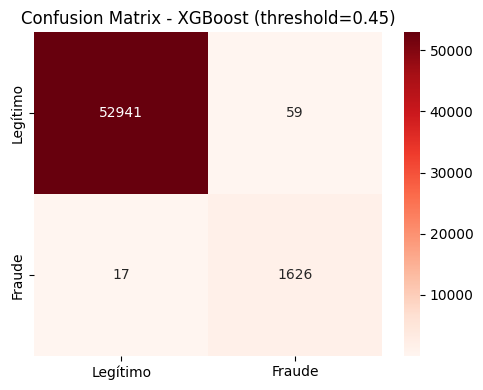

In [44]:
y_pred_best = (proba_xgb >= best_threshold).astype(int)

print(f'Evaluación XGBoost con threshold = {best_threshold:.2f}')
print('='*50)
print(classification_report(y_test, y_pred_best, target_names=['Legítimo', 'Fraude']))
print(f'ROC-AUC: {roc_auc_score(y_test, proba_xgb):.4f}')

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legítimo', 'Fraude'],
            yticklabels=['Legítimo', 'Fraude'])
plt.title(f'Confusion Matrix - XGBoost (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_xgb_best_threshold.png', dpi=150)
plt.show()

## 11 - Importancia de features · XGBoost

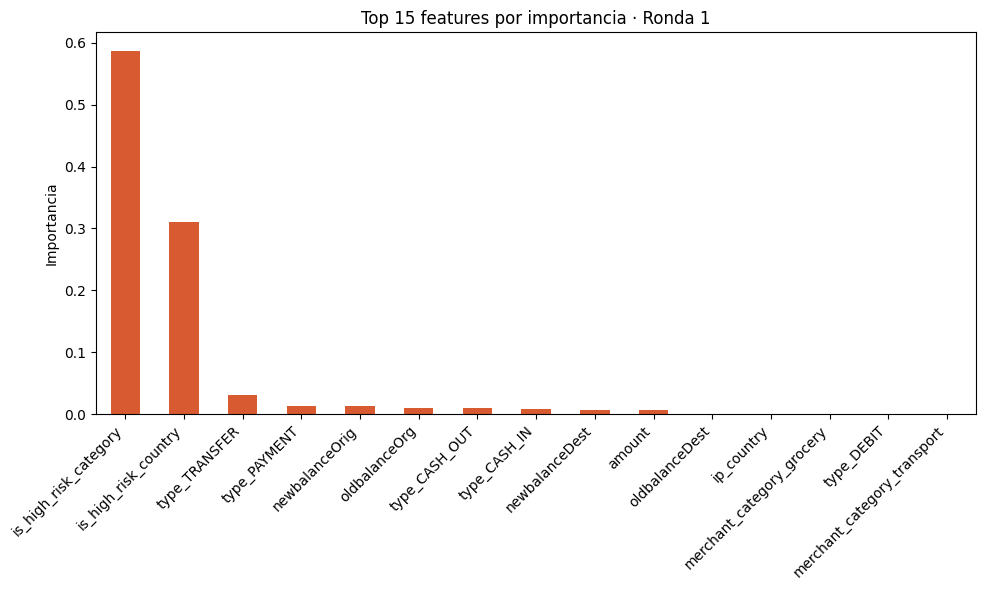


Top 10 features:
is_high_risk_category    0.587495
is_high_risk_country     0.310551
type_TRANSFER            0.030847
type_PAYMENT             0.013792
newbalanceOrig           0.013426
oldbalanceOrg            0.009898
type_CASH_OUT            0.009404
type_CASH_IN             0.008271
newbalanceDest           0.007322
amount                   0.007111
dtype: float32


In [45]:
feature_names = (
    num_features
    + pipe_xgb.named_steps['preprocessor']
      .named_transformers_['cat_ohe']
      .get_feature_names_out(cat_features_ohe).tolist()
    + cat_features_te
)

importances = pipe_xgb.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='bar', color='#D85A30')
plt.title('Top 15 features por importancia · Ronda 1')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/feature_importance_r1.png', dpi=150)
plt.show()

print("\nTop 10 features:")
print(feat_imp.head(10))

## 12 - Serialización del modelo

In [46]:
joblib.dump(pipe_xgb, '../models/xgb_fraud_pipeline.joblib')
joblib.dump(float(best_threshold), '../models/best_threshold.joblib')

print('Modelo guardado en models/xgb_fraud_pipeline.joblib')
print(f'Threshold guardado: {best_threshold:.2f}')

Modelo guardado en models/xgb_fraud_pipeline.joblib
Threshold guardado: 0.45
